# Introduction

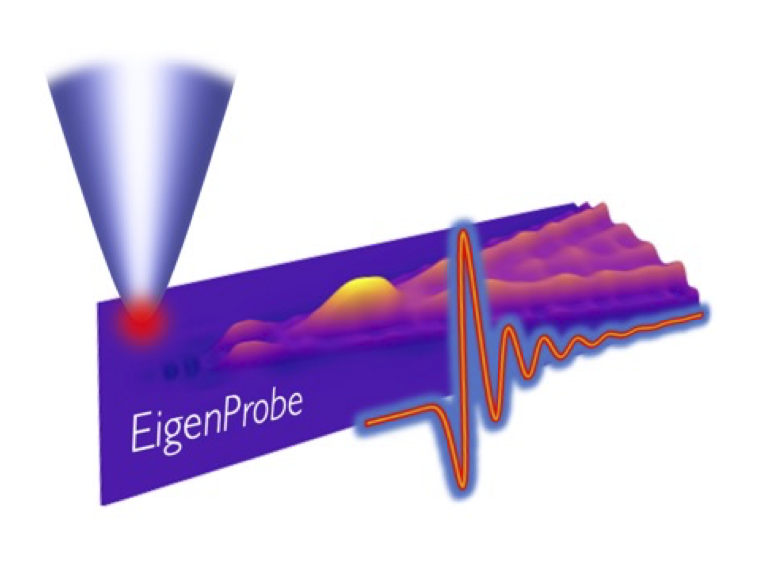

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

# Imports

## General Imports

In [2]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload
import numpy as np

## Specialized Imports

In [3]:
from EigenProbe.common.baseclasses import AWA 
from EigenProbe.common.misc import flatten
from EigenProbe.common import numerical_recipes as numrec

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

# It is known that `sympy` wraps `numpy` universal functions in a way that conflicts with `numba`.  Avoid importing `Materials` until necessary.
#from NearFieldOptics import Materials as M # https://github.com/asmcleod/NearFieldOptics.git
#from NearFieldOptics.Materials import material_types,TransferMatrixMedia

## EigenProbe tools

In [4]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Build a custom probe

In [5]:
probe_name = 'MyProbe'
#probe_name = 'MidIRHyperboloid_FreqDepNormalization_L=%imicrons'%(L*1e4,)
print('Building probe %s...'%probe_name)
P=EP.Probe(name=probe_name,taper_angle=15)

Building probe MyProbe...
<__init__._ProbesCollection.__setitem__>:
	Registering probe "MyProbe"...
<__init__.Probe.__init__>:
	Generating probe "MyProbe"...
<RotationalMoM.get_BoR_radii>:
	Getting geometry for selection "hyperboloid"...
<RotationalMoM.BodyOfRevolution.__init__>:
	Re-meshing provided geometry to quadrature points along annular coordinate `t`...
<RotationalMoM.BodyOfRevolution.__init__>:
	Discretizing body of revolution over 382 annular nodes and 2 subnodes...


## Examine the probe geometry

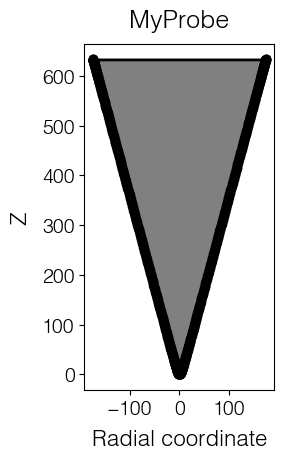

In [6]:
P.plot_geometry()

probe_radii=P.get_radii()
probe_zs = P.get_zs()

probe_radii = np.append(-probe_radii[::-1], probe_radii)
probe_zs = np.append(probe_zs[::-1], probe_zs)

# Solve for response to an external field

## Generate and visualize the external field

The probe-sample distance is 1.00..


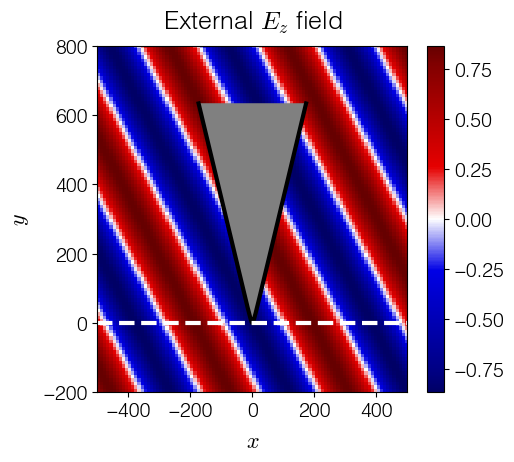

In [7]:
excitation = EP.EPlaneWaveFF(angle=60, k=P.get_k(), e0 = -1)

xs = np.linspace(-500,500,100)
zs = np.linspace(-200,800,100)
Zs,Xs = np.meshgrid(zs,xs)

_,_,E_ext_z = excitation(x=Xs,y=0,z=Zs)
E_ext_z = AWA(E_ext_z,axes=[xs,zs],axis_names=['$x$','$y$'])

plt.figure()
E_ext_z.real.plot(cmap='BWR')
plt.title('External $E_z$ field')

probe_sample_gap = 1 # Change as desired!
P.set_gap(probe_sample_gap)
gap = P.get_gap()
print('The probe-sample distance is %1.2f..'%gap)

plt.fill_between(probe_radii,probe_zs,probe_zs.max(),color='gray')
plt.plot(probe_radii,probe_zs,color='k')
plt.axhline(-gap,ls='--',color='w')

## Compute probe response, with and without a reflective surface nearby

In [8]:
gap = 0.5

#--- Without any surface nearby
surface_reflectivity = 0
Q1=P.solve_induced_charge_direct(excitation=excitation,
                                rho=surface_reflectivity) # Current elements along the probe (charge is legacy misnomer)

#--- With a metallic surface
surface_reflectivity = 1
Q2=P.solve_induced_charge_direct(excitation=excitation,
                                rho=surface_reflectivity) # Current elements along the probe (charge is legacy misnomer)

annular_areas = 2*np.pi*P.get_radii()*P.get_weights() # Surface area of each annulus in the probe discretization

J1 = Q1 / annular_areas # Current density along the probe
J2 = Q2 / annular_areas # Current density along the probe

<RotationalMoM.ImpedanceMatrix>:
	Preparing dynamic self impedance matrix at k=0.019...
	Progress: 99.74%	Total quadrature time: 12.84s, time per quadrature evaluation: 8.80E-05s
<RotationalMoM.ImpedanceMatrix>:
	Preparing quasistatic mirror impedance matrix at k=0...
	Progress: 99.74%	Total quadrature time: 5.48s, time per quadrature evaluation: 3.76E-05s


## Examine current density excited on the probe

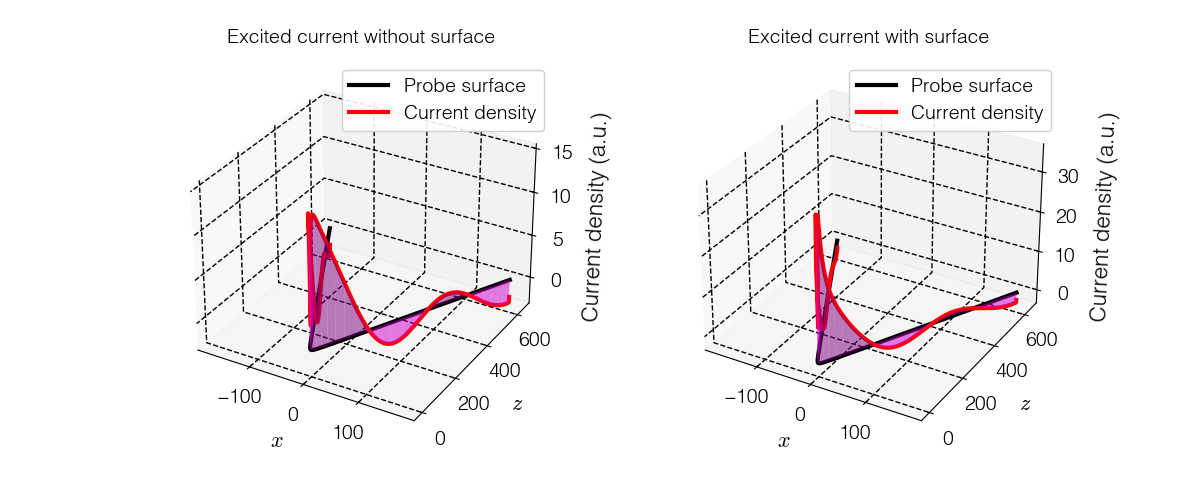

In [9]:
%matplotlib widget

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

ax1.plot(probe_radii, probe_zs, 0,color='k',label='Probe surface')

J1s = np.append(J1[::-1],J1)
ax1.plot(probe_radii, probe_zs, J1s.imag, color='r',label='Current density')

X=np.vstack((probe_radii,probe_radii))
Y=np.vstack((probe_zs,probe_zs))
Z=np.vstack(([0]*len(J1s),J1s.imag))
ax1.plot_surface(X, Y, Z, color=(1,0,1), alpha=0.5)

# 5. Customize the labels and title
ax1.set_title("Excited current without surface", fontsize=14)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$z$")
ax1.set_zlabel("Current density (a.u.)")
ax1.legend()


ax2.plot(probe_radii, probe_zs, 0,color='k',label='Probe surface')

J2s = np.append(J2[::-1],J2)
ax2.plot(probe_radii, probe_zs, J2s.imag, color='r',label='Current density')

X=np.vstack((probe_radii,probe_radii))
Y=np.vstack((probe_zs,probe_zs))
Z=np.vstack(([0]*len(J2s),J2s.imag))
ax2.plot_surface(X, Y, Z, color=(1,0,1), alpha=0.5)

# 5. Customize the labels and title
ax2.set_title("Excited current with surface", fontsize=14)
ax2.set_xlabel("$x$")
ax2.set_ylabel("$z$")
ax2.set_zlabel("Current density (a.u.)")
ax2.legend()

# 6. Display the plot
plt.show()
plt.tight_layout()


## Compute the field scattered by the probe

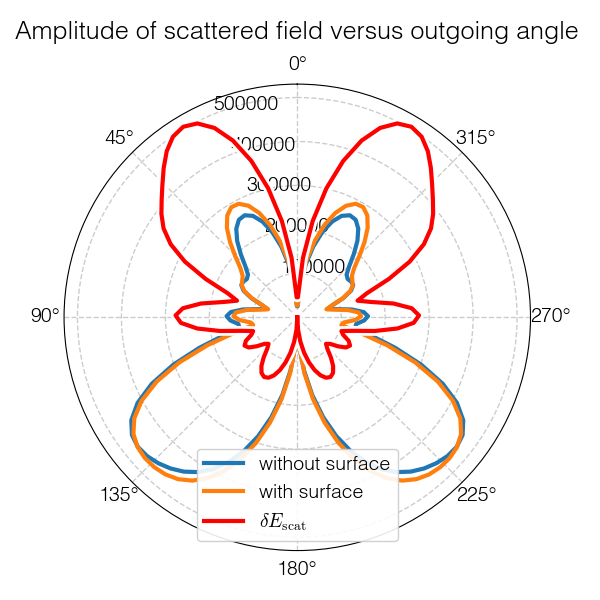

In [10]:
angles = np.linspace(-180,180,100)
scat1 = P.get_brightness(Q1, k=None, illum_angles=angles)
scat2 = P.get_brightness(Q2, k=None, illum_angles=angles)
scat_diff=scat2-scat1

fig, ax = plt.subplots(figsize=(6,6),subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
plt.plot(np.deg2rad(angles),np.abs(scat1),label='without surface')
plt.plot(np.deg2rad(angles),np.abs(scat2),label='with surface')
plt.plot(np.deg2rad(angles),5*np.abs(scat_diff),color='w',lw=7)
plt.plot(np.deg2rad(angles),5*np.abs(scat_diff),color='r',label='$\delta E_\mathrm{scat}$')

plt.legend(loc='lower center')

plt.title('Amplitude of scattered field versus outgoing angle')
plt.tight_layout()



# Compute probe eigenmodes

Computing probe-sample eigenmodes for a probe-surface separation of 1.00...


Text(-8.949120076497397, 0.5, 'Eigenvalues $\\rho_\\nu$')

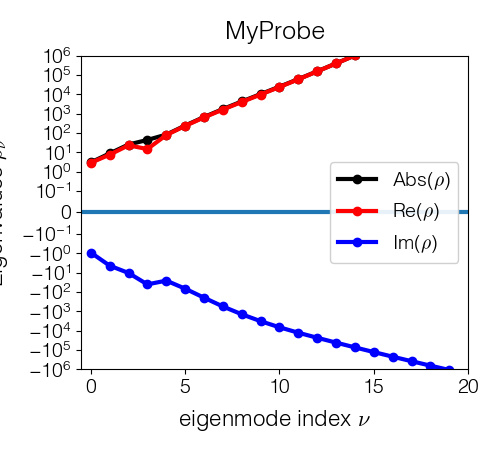

In [11]:
print('Computing probe-sample eigenmodes for a probe-surface separation of %1.2f...'%P.get_gap())
rhos,Js = P.solve_eigenmodes(plot=False)

P.plot_eigenrhos() # Plot the eigenvalues
plt.xlabel(r'eigenmode index $\nu$')
plt.ylabel(r'Eigenvalues $\rho_\nu$')
plt.tight_layout()

## Visualize eigenmode

In [12]:
nu=5 # eignemode index
Q_nu = P.get_eigencharges()[nu]
rho_nu = P.get_eigenrhos()[nu]

span = 5*P.get_a()
rs = np.linspace(0,span,100)
zs = np.linspace(0,2*span,200)
Er,Ez = P.computeEfieldImages(Q_nu, rs, zs, rho=rho_nu)

Text(0.5, 1.0, '$E_z$ field for eigenmode $\\nu=5$')

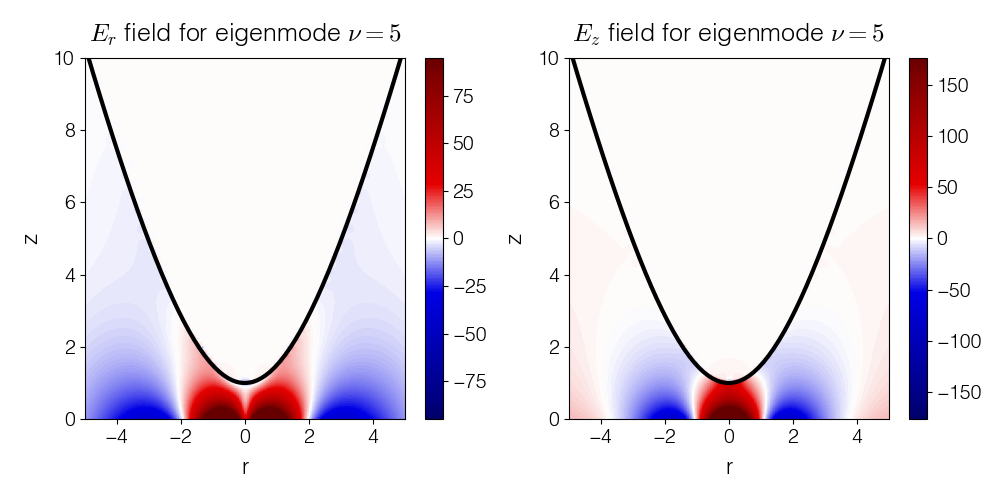

In [13]:
plt.figure(figsize=(10,5))

ax1=plt.subplot(121)

Er.real.plot(cmap='BWR')
cl = np.abs(Er.real).max()/2
plt.clim(-cl,cl)

plt.plot(probe_radii,P.get_gap()+probe_zs,color='k')
plt.xlim(*Er.axis_limits[0])
plt.ylim(*Er.axis_limits[1])
plt.tight_layout()
plt.title(r'$E_r$ field for eigenmode $\nu=%i$'%nu)

ax1=plt.subplot(122)

Ez.real.plot(cmap='BWR')
cl = np.abs(Ez.real).max()/2
plt.clim(-cl,cl)

plt.plot(probe_radii,P.get_gap()+probe_zs,color='k')
plt.xlim(*Ez.axis_limits[0])
plt.ylim(*Ez.axis_limits[1])
plt.tight_layout()
plt.title(r'$E_z$ field for eigenmode $\nu=%i$'%nu)

# Simulate an s-SNOM spectroscopy experiment

## Generate an interesting heterostructure material

This heterostructure could represent a graphene field-effect transistor (FET)

------- Graphene -------

----- SiO2 (100 nm) ----

--- Si (semi-infinite) ---

In [14]:
from EigenProbe import Materials as M

Graphene_active = M.SingleLayerGraphene(chemical_potential=2000,gamma=200) # Graphene has carriers; chemical potential (like every quantity in `Materials`) is in wavneumbers
Graphene_inactive = M.SingleLayerGraphene(chemical_potential=100,gamma=200) # Graphene is depleted

thickness_nm = 100
sio2_layer = (M.SiO2_300nm, thickness_nm*1e-7) # thickness should be in cm
heterostructure_active = M.LayeredMediaTM(Graphene_active,sio2_layer,exit=M.Si)
heterostructure_inactive = M.LayeredMediaTM(sio2_layer,exit=M.Si)

<material_types.TabulatedMaterialFromFile.__init__>:
	Loading tabulated material data from file "Bi2Se3_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "PMMA_epsilon.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "sio2_300nm_extracted_epsilon_cone_A=2a.pickle"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "TaS2_eps_230K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "TaS2_eps_30K.csv"...
<material_types.TabulatedMaterialFromFile.__init__>:
	<material_types.TabulatedMaterialFromFile.__init__>:
		Loading tabulated material data from file "

## Examine the reflectivity of the heterostructure using Transfer Matrix method

/usr/local/Cellar/micromamba/2.8.1/envs/EigenProbe/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


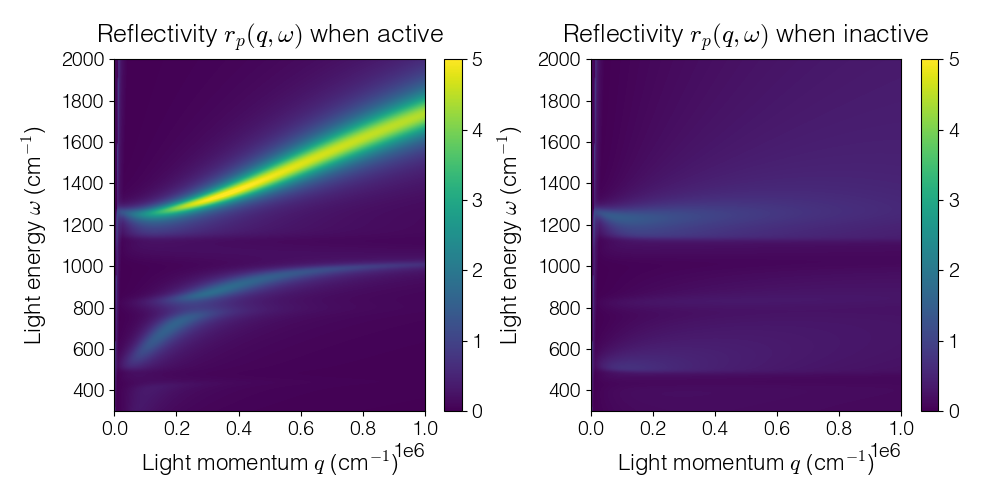

In [15]:
freqs_wn = np.linspace(300,2000,500) # Energies of light, in wavenumbers

q0 = 1/1e-6 # Evanescent field momentum that is well in the quasi-electrostatic regime, also in wavenumbers

q_vals = np.linspace(0,q0,500)


plt.figure(figsize=(10,5))

plt.subplot(121)

rp = heterostructure_active.reflection_p(freqs_wn,q_vals)
rp.imag.T.plot()
plt.clim(0,5)
plt.xlabel(r'Light momentum $q$ (cm$^{-1}$)')
plt.ylabel(r'Light energy $\omega$ (cm$^{-1}$)')
plt.title(r'Reflectivity $r_p(q,\omega)$ when active')
plt.tight_layout()

plt.subplot(122)

rp = heterostructure_inactive.reflection_p(freqs_wn,q_vals)
rp.imag.T.plot()
plt.clim(0,5)
plt.xlabel(r'Light momentum $q$ (cm$^{-1}$)')
plt.ylabel(r'Light energy $\omega$ (cm$^{-1}$)')
plt.title(r'Reflectivity $r_p(q,\omega)$ when inactive')
plt.tight_layout()

## Compute response of the probe over the heterostructure

In [16]:
# What is the conversion factor between (reciprocal) "probe length units" and wavenumbers?
probe_radius_nm = 20
probe_radius_cm = 1e-7 * probe_radius_nm
conversion = 1/probe_radius_cm # from probe units to wavenumbers

rp_wrapped = EP.wrap_rp(rp=heterostructure_active.reflection_p,
                         freq_to_wn=conversion,
                         q_to_wn=conversion)

In [17]:
freq = 600/conversion # 1000 wavenumbers but in probe units

gapmin = P.get_a()/10 # minimum probe-sample distance
gapmax = P.get_a()*100 # maximum probe-sample distance

result = P.EradVsGap(freq=freq, gapmin=gapmin, gapmax=gapmax,rp=rp_wrapped,
                     Ngaps=100, Nkappas=244*2, # the number of "kappa" values describes the number of quadrature points in a momentum-integral (should be >244) 
                     subtract_background=True) # We are subtracting the probe response that would be present with no surface nearby ("background")

<__init__.Probe.get_eigenbrightness>:
	<__init__.Probe.get_eigenbrightness>:
		Computing eigenbrightness at k=0.02...
<__init__.Probe.EradVsGap>:
	<__init__.Probe.EradVsGap>:
		Computing response for 100 gaps at freq=0.0012...
<__init__.Probe.getFourPotentialPropagators>:
	<__init__.Probe.getFourPotentialPropagators>:
		Computing field propagators at k=0...
	Including evanescent (near-field) waves..


/Users/alexandersmcleod/tools/python/EigenProbe/__init__.py:1228: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Erad = complex(Vn.T @ self.ScatMat @ Vn)


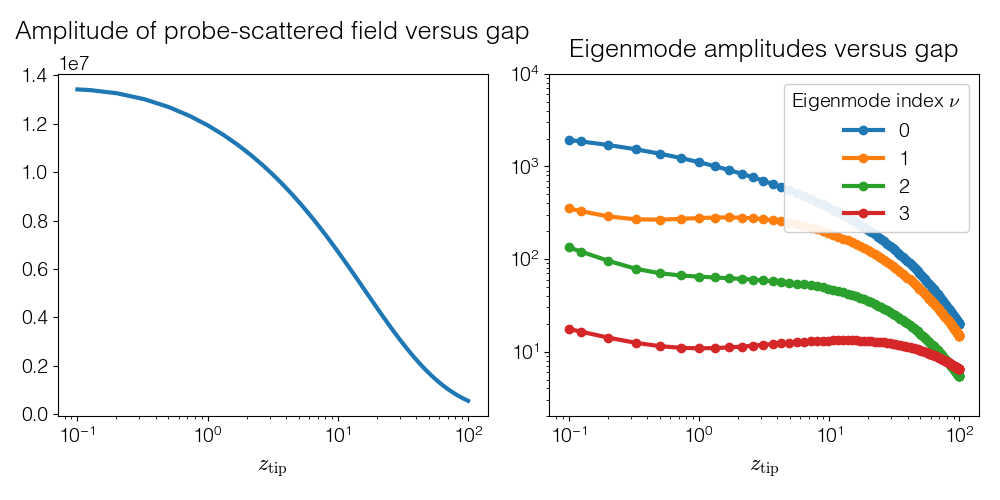

In [18]:
plt.figure(figsize=(10,5))

plt.subplot(121)
Erad = result['Erad'] # Radiated field, averaged over excitation and emission angles to/from the eigenmodes
np.abs(Erad).plot(plotter=plt.semilogx)
plt.title('Amplitude of probe-scattered field versus gap')

plt.subplot(122)
for nu in np.arange(4):
    np.abs(result['eigenamplitude'].cslice[:,nu]).plot(plotter=plt.loglog,label=nu,marker='o')
plt.legend(title=r'Eigenmode index $\nu$',loc='upper right')
plt.tight_layout()
plt.ylim(2,1e4)
plt.title('Eigenmode amplitudes versus gap')
plt.tight_layout()

## Predict an s-SNOM demodulated scattering spectrum

In [19]:
freqs_wn = np.linspace(300,1500,100) # Energies of light, in wavenumbers

# This calculation requires computing the probe-scattered field at every energy and at every probe-sample gap distance
#  while tapping over `amplitude_nm`, then demodulating, then normalizing the result to the same calculation over a reference material (here, gold)..
# So the calculation can be expensive!
# Other notebooks show how to speed this up considerably.
result_active = P.getNormalizedSignal(freqs_wn, rp=heterostructure_active.reflection_p,
                                        a_nm=30, amplitude_nm=50, Ngaps=24,
                                        rp_norm = M.Au.reflection_p,
                                        norm_single_freq = True,Nkappas=244)


result_inactive = P.getNormalizedSignal(freqs_wn, rp=heterostructure_inactive.reflection_p,
                                        a_nm=30, amplitude_nm=50, Ngaps=24,
                                        rp_norm = M.Au.reflection_p,
                                        norm_single_freq = True,Nkappas=244)

amplitude= 1.6666666666666667
gapmin= 0.005
<__init__.Probe.EradVsGap>:
	<__init__.Probe.EradVsGap>:
		Computing response for 24 gaps at freq=0.0011369288931406154...
<__init__.Probe.getFourPotentialPropagators>:
	<__init__.Probe.getFourPotentialPropagators>:
		Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	<__init__.Probe.EradVsGap>:
		Computing response for 24 gaps at freq=0.0011828654140755897...
<__init__.Probe.getFourPotentialPropagators>:
	<__init__.Probe.getFourPotentialPropagators>:
		Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	<__init__.Probe.EradVsGap>:
		Computing response for 24 gaps at freq=0.001228801935010564...
<__init__.Probe.getFourPotentialPropagators>:
	<__init__.Probe.getFourPotentialPropagators>:
		Computing field propagators at k=0...
	Including evanescent (near-field) waves..
<__init__.Probe.EradVsGap>:
	<__init__.Probe.EradVsGap>:
		C

In [20]:
print(result_active.keys())

dict_keys(['Erad', 'eigenamplitude', 'Sn', 'Sn_norm'])


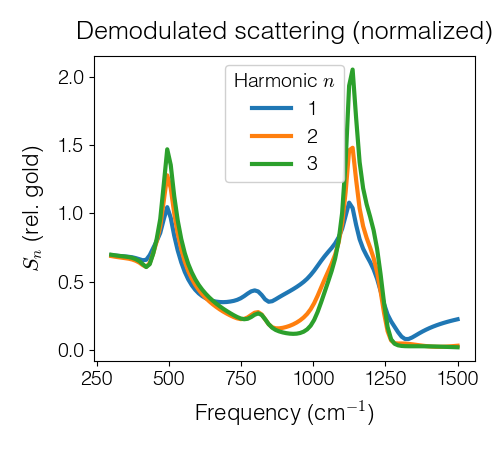

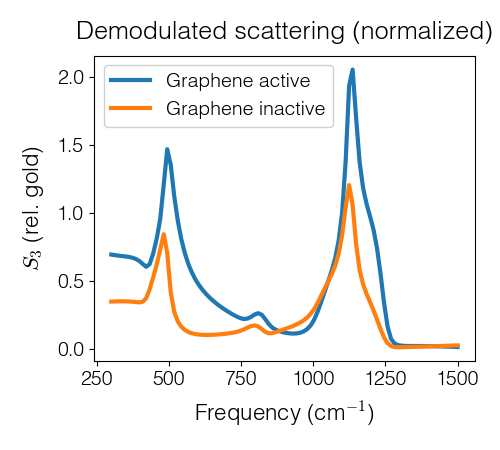

In [21]:
harmonics=[1,2,3]

plt.figure()
for harmonic in harmonics:
    Sn = result_active['Sn_norm'][harmonic]
    np.abs(Sn).plot(label=harmonic)
plt.legend(title='Harmonic $n$')
plt.title('Demodulated scattering (normalized)')
plt.ylabel(r'$S_n$ (rel. gold)')
plt.tight_layout()

plt.figure()
harmonic = 3
np.abs(result_active['Sn_norm'][harmonic]).plot(label='Graphene active')
np.abs(result_inactive['Sn_norm'][harmonic]).plot(label='Graphene inactive')
plt.legend()
plt.ylabel(r'$S_%i$ (rel. gold)'%harmonic)
plt.title('Demodulated scattering (normalized)')
plt.tight_layout()
